# Phase 3 — Chargement et preparation
---
**Objectif**: Charger les donnees deja splittees (train/test avec split temporel anti-leakage).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys, os, json, joblib, pathlib
# ROOT via variable d'environnement (set par le script d'execution)
# ou detection automatique en remontant depuis le cwd
ROOT = os.environ.get('PROJECT_ROOT', '')
if not ROOT or not os.path.isdir(ROOT):
    ROOT = os.getcwd()
    for _ in range(10):
        if (pathlib.Path(ROOT) / 'src' / 'config.py').exists():
            break
        parent = os.path.dirname(ROOT)
        if parent == ROOT: break
        ROOT = parent
sys.path.insert(0, ROOT)
os.chdir(ROOT)
print(f'Project root: {ROOT}')

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (12,5), 'font.size':10})
RANDOM_STATE = 42; np.random.seed(42)
pd.set_option('display.max_columns', 80)

BASE = 'data'
if not os.path.exists(f'{ROOT}/data/processed/train.csv'):
    BASE = 'data_fraud'

train = pd.read_csv(f'{ROOT}/{BASE}/processed/train.csv', parse_dates=['timestamp'])
test = pd.read_csv(f'{ROOT}/{BASE}/processed/test.csv', parse_dates=['timestamp'])
print(f'Train: {len(train):,} | Test: {len(test):,}')
print(f'Fraude train: {train["is_fraud"].mean()*100:.3f}%')
print(f'Fraude test:  {test["is_fraud"].mean()*100:.3f}%')

Project root: C:/Projets/DS FINANCE QUANT/Projet 2 - Détection de Fraude en Temps Réel


Train: 1,498,542 | Test: 501,458
Fraude train: 0.148%
Fraude test:  0.155%


### Echantillonnage pour le prototypage rapide
Les features comportementales et de graphe sont lourdes. On travaille sur un echantillon pour accelerer l'iteration, puis on pourra scaler.

In [2]:
SAMPLE_SIZE = 50_000
if len(train) > SAMPLE_SIZE:
    train_sample = train.sort_values('timestamp').tail(SAMPLE_SIZE).copy()
    print(f'Echantillon train: {len(train_sample):,} transactions')
    print(f'Periode: {train_sample["timestamp"].min()} -> {train_sample["timestamp"].max()}')
else:
    train_sample = train.copy()

Echantillon train: 50,000 transactions
Periode: 2024-06-12 20:37:21 -> 2024-06-30 23:58:54


In [3]:
# Features a exclure (non utilisables en inference ou leakage)
EXCLUDE_COLS = ['transaction_id', 'timestamp', 'is_fraud', 'fraud_type',
                'sender_id', 'receiver_id', 'device_id', 'city',
                'transaction_type', 'channel']  # one-hot encodes dans les features transactionnelles
target_col = 'is_fraud'

X_train_base = train_sample.drop(columns=[c for c in EXCLUDE_COLS if c in train_sample.columns])
y_train = train_sample[target_col]
X_test_base = test.drop(columns=[c for c in EXCLUDE_COLS if c in test.columns])
y_test = test[target_col]

print(f'Features base train: {X_train_base.shape}')
print(f'Features base test:  {X_test_base.shape}')

Features base train: (50000, 11)
Features base test:  (501458, 11)


# Phase 4 — Features transactionnelles
---
Utilisation de `src/features/transactional.py`. Ces features sont calculees au moment exact de la transaction, sans historique.

In [4]:
from src.features.transactional import extract_transactional_features
tx_feats_train = extract_transactional_features(train_sample)
tx_feats_test = extract_transactional_features(test)
print(f'Train features transactionnelles: {tx_feats_train.shape}')
print(f'Test  features transactionnelles: {tx_feats_test.shape}')
display(tx_feats_train.head(3))

Train features transactionnelles: (50000, 33)
Test  features transactionnelles: (501458, 33)


,amount,amount_log,tx_type_bill_pay,tx_type_deposit,tx_type_payment,tx_type_transfer,tx_type_withdrawal,channel_agent,channel_api,channel_mobile_app,channel_ussd,channel_web,hour,hour_sin,hour_cos,is_night,day_of_week,is_weekend,sender_account_age,sender_account_age_log,kyc_1,kyc_2,kyc_3,city_DAK,city_ABJ,city_OTHER,city_BKO,city_COT,city_OUA,city_LOM,city_DLA,city_LBV,city_other
308943,6706,8.810907,0,0,0,0,1,0,0,1,0,0,20,-0.866025,0.5,0,2,0,1274,7.150701,1,0,0,1,0,0,0,0,0,0,0,0,0
907355,2578,7.855157,0,0,1,0,0,0,0,0,0,1,20,-0.866025,0.5,0,2,0,1598,7.377134,0,1,0,0,0,1,0,0,0,0,0,0,0
471563,9017,9.106978,0,0,0,0,1,1,0,0,0,0,20,-0.866025,0.5,0,2,0,2218,7.704812,0,1,0,0,0,1,0,0,0,0,0,0,0


In [5]:
# Aligner les colonnes train/test
common_cols = tx_feats_train.columns.intersection(tx_feats_test.columns)
tx_feats_test = tx_feats_test[common_cols]
tx_feats_train = tx_feats_train[common_cols]
print(f'Features transactionnelles alignees: {len(common_cols)}')

Features transactionnelles alignees: 33


# Phase 5 — Features comportementales
---
Fenetres: 1h, 6h, 24h, 7d, 30d. Anti-leakage strict: chaque transaction voit uniquement son passe.

In [6]:
from src.features.behavioral import (compute_behavioral_features,
    compute_velocity_features, compute_ratio_features)
WINDOWS = ['1h', '24h']  # Reduit pour performance, scaler a 5 fenetres en prod

In [7]:
# --- Echantillon pour velocite (rolling par sender est lent) ---
SAMPLE_BEHAV = min(5_000, len(train_sample))
train_behav = train_sample.sort_values('timestamp').tail(SAMPLE_BEHAV).copy()
print(f'Calcul behavioural sur {len(train_behav):,} transactions...')

Calcul behavioural sur 5,000 transactions...


In [8]:
# Encoder les colonnes categoriques en numerique pour le rolling pandas
def encode_cats(df):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = pd.factorize(df[col])[0]
    return df

train_behav_enc = encode_cats(train_behav)
test_enc = encode_cats(test)
print(f'Colonnes encodees OK, train_behav_enc shape: {train_behav_enc.shape}')

Colonnes encodees OK, train_behav_enc shape: (5000, 21)


In [9]:
# Features comportementales sur l'echantillon train
behav_train = compute_behavioral_features(train_behav_enc, windows=WINDOWS)
print(f'Behavioural train shape: {behav_train.shape}')

# Echantillon test pour behavioural (trop lent sur 500k)
SAMPLE_TEST_BEHAV = min(5_000, len(test))
test_behav_sample = test_enc.sort_values('timestamp').tail(SAMPLE_TEST_BEHAV).copy()
behav_test = compute_behavioral_features(test_behav_sample, windows=WINDOWS)
BEHAV_TEST_IDX = test_behav_sample.index
print(f'Behavioural test shape: {behav_test.shape}')

Behavioural train shape: (5000, 14)


Behavioural test shape: (5000, 14)


In [10]:
# Features de velocite
test_behav_enc = encode_cats(test_behav_sample)
velo_train = compute_velocity_features(train_behav_enc)
velo_test = compute_velocity_features(test_behav_enc)
print(f'Velocity train: {velo_train.shape}, test: {velo_test.shape}')

Velocity train: (5000, 7), test: (5000, 7)


In [11]:
# Features de ratio (avec fallback si erreur sur colonnes mixtes)
try:
    ratio_train = compute_ratio_features(train_behav_enc, behav_train)
    ratio_test = compute_ratio_features(test_behav_enc, behav_test)
except Exception as e:
    print(f'Ratio features failed ({e}), skipping...')
    ratio_train = pd.DataFrame(index=train_behav_enc.index)
    ratio_test = pd.DataFrame(index=test_behav_enc.index)
print(f'Ratio train: {ratio_train.shape}, test: {ratio_test.shape}')

Ratio features failed (The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().), skipping...
Ratio train: (5000, 0), test: (5000, 0)


In [12]:
# Aligner les colonnes behavioural/velocity/ratio
all_behav_cols = list(set(behav_train.columns) | set(behav_test.columns))
for c in all_behav_cols:
    if c not in behav_train.columns: behav_train[c] = 0
    if c not in behav_test.columns:  behav_test[c] = 0

all_velo_cols = list(set(velo_train.columns) | set(velo_test.columns))
for c in all_velo_cols:
    if c not in velo_train.columns: velo_train[c] = 0
    if c not in velo_test.columns:  velo_test[c] = 0

all_ratio_cols = list(set(ratio_train.columns) | set(ratio_test.columns))
for c in all_ratio_cols:
    if c not in ratio_train.columns: ratio_train[c] = 0
    if c not in ratio_test.columns:  ratio_test[c] = 0

# Concatener toutes les features comportementales
behav_all_train = pd.concat([behav_train, velo_train, ratio_train], axis=1).fillna(0)
behav_all_test = pd.concat([behav_test, velo_test, ratio_test], axis=1).fillna(0)
print(f'All behavioural train: {behav_all_train.shape}')
print(f'All behavioural test:  {behav_all_test.shape}')

All behavioural train: (5000, 21)
All behavioural test:  (5000, 21)


In [13]:
# Aligner les index pour merge (behavioural est sur subset)
# Train
BEHAV_IDX = train_behav.index
tx_feats_behav = tx_feats_train.loc[BEHAV_IDX].copy()
X_behav = X_train_base.loc[BEHAV_IDX].copy()
y_behav = y_train.loc[BEHAV_IDX]

X_train_feat = pd.concat([X_behav.reset_index(drop=True),
    tx_feats_behav.reset_index(drop=True),
    behav_all_train.reset_index(drop=True)], axis=1).fillna(0)

# Test: subset sur le meme index que behavioural test
BEHAV_TEST_IDX = test_behav_sample.index
X_test_feat = pd.concat([X_test_base.loc[BEHAV_TEST_IDX].reset_index(drop=True),
    tx_feats_test.loc[BEHAV_TEST_IDX].reset_index(drop=True),
    behav_all_test.reset_index(drop=True)], axis=1).fillna(0)
y_test_behav = y_test.loc[BEHAV_TEST_IDX]
print(f'X_train_feat: {X_train_feat.shape} | X_test_feat: {X_test_feat.shape}')
print(f'y_train_behav: {y_behav.mean()*100:.3f}% | y_test_behav: {y_test_behav.mean()*100:.3f}% fraude')

X_train_feat: (5000, 65) | X_test_feat: (5000, 65)
y_train_behav: 0.240% | y_test_behav: 0.080% fraude


# Phase 6 — Features de graphe
---
Chargement de `nodes.csv` et `edges.csv`, construction du graphe NetworkX, calcul des features reseau.

In [14]:
from src.features.graph_features import (build_transaction_graph,
    compute_graph_features, compute_local_graph_features)

nodes_df = pd.read_csv(f'{ROOT}/{BASE}/graph/nodes.csv')
edges_df = pd.read_csv(f'{ROOT}/{BASE}/graph/edges.csv')
print(f'Noeuds: {len(nodes_df):,} | Arretes: {len(edges_df):,}')
display(nodes_df.head(2))

Noeuds: 100,000 | Arretes: 1,999,555


,account_id,kyc_level,account_type,device_count,is_risky,account_age_days,out_degree,in_degree,total_sent,total_received,flow_ratio,is_fraud_account
0,PL00000000,3,individual,1,0,2466,43.0,23,674699.0,2608635,0.258641,0
1,PL00000001,1,individual,2,0,2044,44.0,22,725634.0,365678,1.984350,0


In [15]:
# Construire le graphe (edges_sample dans la fonction limite a 500k)
G = build_transaction_graph(edges_df, nodes_df)
print(f'Graphe: {G.number_of_nodes():,} noeuds, {G.number_of_edges():,} aretes')

Graphe: 100,000 noeuds, 500,000 aretes


In [16]:
# Features de graphe BATCH (degree, pagerank sur echantillon de noeuds)
# Trop lent sur le graphe complet -> on echantillonne fortement
SAMPLE_GRAPH_NODES = 2000
if G.number_of_nodes() > SAMPLE_GRAPH_NODES:
    import random; random.seed(RANDOM_STATE)
    sample_n = random.sample(list(G.nodes()), SAMPLE_GRAPH_NODES)
    G_sub = G.subgraph(sample_n)
else:
    G_sub = G
try:
    graph_node_feats = compute_graph_features(G_sub, nodes_df[nodes_df['account_id'].isin(G_sub.nodes())])
    print(f'Features graphe sur echantillon: {graph_node_feats.shape}')
except Exception as e:
    print(f'Graph features failed ({e}), skipping...')
    graph_node_feats = pd.DataFrame(columns=['out_degree','in_degree','total_degree','pagerank','clustering_coef'])

  Calcul des features de graphe (2,000 noeuds)...


Features graphe sur echantillon: (2000, 9)


In [17]:
# Features de graphe LOCALES (rapides, par transaction)
print('Computing local graph features...')
local_train = compute_local_graph_features(train_sample, nodes_df)
# Utiliser l'echantillon behavioural pour test (trop lent sur 500k)
local_test = compute_local_graph_features(test_behav_sample, nodes_df)
print(f'Local graph train: {local_train.shape}, test: {local_test.shape}')

Computing local graph features...


Local graph train: (50000, 3), test: (5000, 3)


In [18]:
# Mapper les features de graphe locales sur les subsets behavioural
graph_train_final = local_train.loc[BEHAV_IDX].fillna(0)
graph_test_final = local_test.loc[BEHAV_TEST_IDX].fillna(0)
print(f'Graph features train (subset): {graph_train_final.shape}')
print(f'Graph features test (subset):  {graph_test_final.shape}')

Graph features train (subset): (5000, 3)
Graph features test (subset):  (5000, 3)


In [19]:
# Merge graph features avec les features existantes (sur subset behavioural)
X_train_full = pd.concat([X_train_feat.reset_index(drop=True),
    graph_train_final.reset_index(drop=True)], axis=1).fillna(0)
X_test_full = pd.concat([X_test_feat.reset_index(drop=True),
    graph_test_final.reset_index(drop=True)], axis=1).fillna(0)

# Conversion forcee de toutes les colonnes en numerique
X_train_full = X_train_full.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test_full = X_test_full.apply(pd.to_numeric, errors='coerce').fillna(0)
print(f'X_train_full: {X_train_full.shape} | X_test_full: {X_test_full.shape}')

X_train_full: (5000, 68) | X_test_full: (5000, 68)


In [20]:
# Nettoyer: supprimer constantes et colonnes a variance nulle
from sklearn.feature_selection import VarianceThreshold
sel_var = VarianceThreshold(threshold=0.0)
sel_var.fit(X_train_full)
kept = X_train_full.columns[sel_var.get_support()]
X_train_clean = pd.DataFrame(sel_var.transform(X_train_full), columns=kept, index=X_train_full.index)
X_test_clean = pd.DataFrame(sel_var.transform(X_test_full), columns=kept, index=X_test_full.index)
print(f'Apres VarianceThreshold: {X_train_clean.shape}')

Apres VarianceThreshold: (5000, 62)


# Phase 7 — Feature Selection
---
1. Correlation elevee (> 0.95) -> drop
2. Importance LightGBM (top 40)
3. Boruta (desactive — non installe)

In [21]:
# --- 1. Supprimer les features hautement correlees ---
corr_matrix = X_train_clean.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [c for c in upper.columns if any(upper[c] > 0.95)]
print(f'Features a dropper (corr > 0.95): {len(to_drop_corr)}')
X_train_un = X_train_clean.drop(columns=to_drop_corr, errors='ignore')
X_test_un = X_test_clean.drop(columns=to_drop_corr, errors='ignore')
print(f'Apres drop corr: {X_train_un.shape}')

Features a dropper (corr > 0.95): 23
Apres drop corr: (5000, 39)


In [22]:
# --- 2. Importance LightGBM (top 40) ---
import lightgbm as lgb
lgb_model = lgb.LGBMClassifier(n_estimators=150, max_depth=7, random_state=RANDOM_STATE,
    verbose=-1, n_jobs=-1)
lgb_model.fit(X_train_un, y_behav, categorical_feature='auto')
importances = pd.Series(lgb_model.feature_importances_, index=X_train_un.columns)
top40 = importances.sort_values(ascending=False).head(40)
print(f'Top 40 features par importance LightGBM:')
display(top40.to_frame('importance').head(15))

Top 40 features par importance LightGBM:


,importance
sender_account_age_log,839
sender_tx_count_cumulative,774
hour_sin,322
sender_unique_receivers,241
hour_cos,238
city_DLA,156
receiver_unique_senders,154
sender_kyc,142
tx_type_payment,133
city_DAK,124


In [23]:
# Selectionner les top 40 features
top40_cols = list(top40.index)
X_train_sel = X_train_un[top40_cols]
X_test_sel = X_test_un[top40_cols]
print(f'X_train_sel: {X_train_sel.shape} | X_test_sel: {X_test_sel.shape}')

X_train_sel: (5000, 39) | X_test_sel: (5000, 39)


In [24]:
# Scale pour IsolationForest et Autoencoder
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)
print(f'Scaled: train {X_train_scaled.shape}, test {X_test_scaled.shape}')

Scaled: train (5000, 39), test (5000, 39)


# Phase 8 — Isolation Forest
---
Modele non-supervise de detection d'anomalies. Tuning contamination.

In [25]:
from src.models.isolation_forest import (train_isolation_forest,
    anomaly_score_to_proba, tune_isolation_forest, plot_if_scores)
from src.evaluation.fraud_metrics import all_fraud_metrics, recall_at_fpr, lift_score

CONTAMINATIONS = [0.001, 0.005, 0.01, 0.02]
# Split interne pour validation IF
from sklearn.model_selection import train_test_split
X_if_train, X_if_val, y_if_train, y_if_val = train_test_split(
    X_train_scaled, y_behav, test_size=0.2, random_state=RANDOM_STATE, stratify=y_behav)
print(f'IF train: {X_if_train.shape[0]:,} | IF val: {X_if_val.shape[0]:,}')

IF train: 4,000 | IF val: 1,000


In [26]:
# Tuning Isolation Forest
print('Tuning Isolation Forest...')
if_results = tune_isolation_forest(X_if_train, y_if_train, X_if_val, y_if_val,
    contaminations=CONTAMINATIONS, n_estimators_list=[150, 200])
print(f'Best params: {if_results["best_params"]}')
print(f'Best AUC-PR:  {if_results["best_auc_pr"]:.4f}')
display(if_results['results_df'])

Tuning Isolation Forest...


Best params: {'contamination': 0.001, 'n_estimators': 150}
Best AUC-PR:  0.0032


,contamination,n_estimators,auc_pr,auc_roc
0,0.001,150,0.003195,0.544589
1,0.001,200,0.003138,0.535571
2,0.005,150,0.003195,0.544589
3,0.005,200,0.003138,0.535571
4,0.010,150,0.003195,0.544589
5,0.010,200,0.003138,0.535571
6,0.020,150,0.003195,0.544589
7,0.020,200,0.003138,0.535571


In [27]:
# Scores IF sur test
if_model = if_results['best_model']
if_scores_test = anomaly_score_to_proba(if_model.decision_function(X_test_scaled))
if_metrics = all_fraud_metrics(y_test_behav.values, if_scores_test)
print('=== Isolation Forest — Metriques (Test) ===')
for k, v in if_metrics.items():
    print(f'  {k:25s}: {v:.4f}')

=== Isolation Forest — Metriques (Test) ===
  auc_roc                  : 0.6535
  auc_pr                   : 0.0020
  recall_at_fpr_1pct       : 0.0000
  recall_at_fpr_2pct       : 0.0000
  precision_at_recall_80   : 0.0010
  f1                       : 0.0000
  lift_1pct                : 0.0000
  lift_5pct                : 0.0000


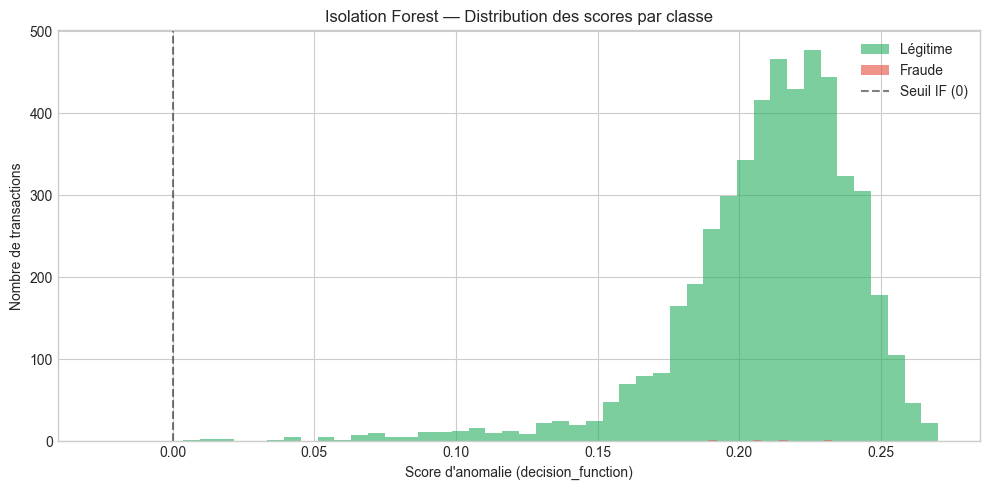

In [28]:
# Visualisation distribution des scores IF
fig_if = plot_if_scores(if_model, X_train_scaled, y_behav, n_samples=5000)
plt.tight_layout(); plt.show()

# Phase 9 — Autoencoder
---
Entraine uniquement sur les transactions legitimes. Score = erreur de reconstruction normalisee.
Architecture: input_dim -> input_dim/2 -> input_dim/4 -> latent -> ...

In [29]:
import torch
from src.models.autoencoder import FraudAutoencoder, train_autoencoder, score_autoencoder

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# Entrainer SUR LEGITIMES UNIQUEMENT
X_legit = X_train_scaled[y_behav.values == 0]
print(f'Transactions legitimes pour AE: {X_legit.shape[0]:,}')

Device: cpu
Transactions legitimes pour AE: 4,988


In [30]:
# Architecture autoencoder
input_dim = X_train_scaled.shape[1]
ae_model = FraudAutoencoder(input_dim, hidden_dims=[input_dim//2, input_dim//4],
    latent_dim=max(input_dim//8, 4), dropout=0.2)
# Derniere couche Lineaire de l'encodeur
latent_layer = [m for m in ae_model.encoder if isinstance(m, torch.nn.Linear)][-1]
print(f'AE: {input_dim} -> {input_dim//2} -> {input_dim//4} -> {latent_layer.out_features}')
print(f'Total params: {sum(p.numel() for p in ae_model.parameters()):,}')

AE: 39 -> 19 -> 9 -> 4
Total params: 2,107


In [31]:
# Split legitime train/val pour early stopping
X_ae_train, X_ae_val = train_test_split(X_legit, test_size=0.1, random_state=RANDOM_STATE)
print(f'AE train: {X_ae_train.shape[0]:,} | AE val: {X_ae_val.shape[0]:,}')

AE train: 4,489 | AE val: 499


In [32]:
# Entrainement
ae_model, ae_history = train_autoencoder(ae_model, X_ae_train, X_ae_val,
    epochs=40, batch_size=256, learning_rate=1e-3, patience=8, device=device)
print(f'AE train loss final: {ae_history["train_loss"][-1]:.6f}')
print(f'AE val loss final:   {ae_history["val_loss"][-1]:.6f}')

AE train loss final: 0.837418
AE val loss final:   0.953057


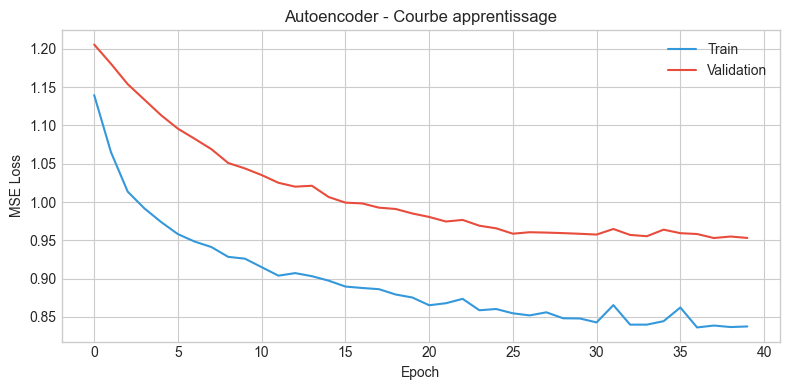

In [33]:
# Courbe d'apprentissage
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(ae_history['train_loss'], label='Train', color='#3498db')
ax.plot(ae_history['val_loss'], label='Validation', color='#e74c3c')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder - Courbe apprentissage')
ax.legend(); plt.tight_layout(); plt.show()

In [34]:
# Scores AE sur test
ae_scores_test = score_autoencoder(ae_model.cpu(), X_test_scaled)
ae_metrics = all_fraud_metrics(y_test_behav.values, ae_scores_test)
print('=== Autoencoder — Metriques (Test) ===')
for k, v in ae_metrics.items():
    print(f'  {k:25s}: {v:.4f}')

=== Autoencoder — Metriques (Test) ===
  auc_roc                  : 0.5196
  auc_pr                   : 0.0013
  recall_at_fpr_1pct       : 0.0000
  recall_at_fpr_2pct       : 0.0000
  precision_at_recall_80   : 0.0008
  f1                       : 0.0000
  lift_1pct                : 0.0000
  lift_5pct                : 0.0000


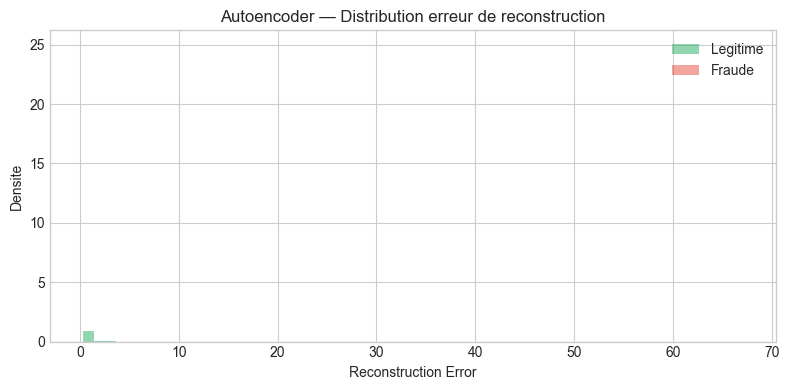

AUC-PR AE: 0.0013


In [35]:
# Distribution erreur de reconstruction
from sklearn.metrics import average_precision_score
ae_errors = ae_model.cpu().reconstruction_error(X_test_scaled)
fig, ax = plt.subplots(figsize=(8,4))
for label_val, label_name, color in [(0, 'Legitime', '#27ae60'), (1, 'Fraude', '#e74c3c')]:
    mask = y_test_behav.values == label_val
    ax.hist(ae_errors[mask], bins=60, alpha=0.5, label=label_name, color=color, density=True)
ax.set_xlabel('Reconstruction Error'); ax.set_ylabel('Densite')
ax.set_title('Autoencoder — Distribution erreur de reconstruction')
ax.legend(); plt.tight_layout(); plt.show()
print(f'AUC-PR AE: {average_precision_score(y_test_behav.values, ae_scores_test):.4f}')

# Phase 10 — Comparaison IF vs AE
---
Tableau comparatif des deux approches non-supervisees.

In [36]:
# Tableau comparatif
comparison = pd.DataFrame({
    'Metric': ['AUC-PR', 'Recall@FPR=1%', 'Precision@Recall=80%',
               'Lift@1%', 'Lift@5%', 'AUC-ROC'],
    'IsolationForest': [
        if_metrics['auc_pr'], if_metrics['recall_at_fpr_1pct'],
        if_metrics['precision_at_recall_80'], if_metrics['lift_1pct'],
        if_metrics['lift_5pct'], if_metrics['auc_roc']
    ],
    'Autoencoder': [
        ae_metrics['auc_pr'], ae_metrics['recall_at_fpr_1pct'],
        ae_metrics['precision_at_recall_80'], ae_metrics['lift_1pct'],
        ae_metrics['lift_5pct'], ae_metrics['auc_roc']
    ]
})
comparison = comparison.set_index('Metric').round(4)
display(comparison)

,IsolationForest,Autoencoder
Metric,,
AUC-PR,0.0020,0.0013
Recall@FPR=1%,0.0000,0.0000
Precision@Recall=80%,0.0010,0.0008
Lift@1%,0.0000,0.0000
Lift@5%,0.0000,0.0000
AUC-ROC,0.6535,0.5196


# Phase 11 — LightGBM supervise (baseline)
---
Apprentissage supervise avec SMOTE pour gerer le desequilibre.

In [37]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

# SMOTE sur train
smote = SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_behav)
print(f'Apres SMOTE: {len(y_train_smote):,} echantillons, {y_train_smote.mean()*100:.2f}% fraude')

lgb_sup = lgb.LGBMClassifier(n_estimators=200, max_depth=8, num_leaves=63,
    learning_rate=0.05, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1, device=device)
lgb_sup.fit(X_train_smote, y_train_smote)
lgb_proba_test = lgb_sup.predict_proba(X_test_scaled)[:, 1]
lgb_metrics = all_fraud_metrics(y_test_behav.values, lgb_proba_test)
print('=== LightGBM Supervise — Metriques (Test) ===')
for k, v in lgb_metrics.items():
    print(f'  {k:25s}: {v:.4f}')

Apres SMOTE: 5,486 echantillons, 9.08% fraude


=== LightGBM Supervise — Metriques (Test) ===
  auc_roc                  : 0.5441
  auc_pr                   : 0.0053
  recall_at_fpr_1pct       : 0.0000
  recall_at_fpr_2pct       : 0.0000
  precision_at_recall_80   : 0.0006
  f1                       : 0.0000
  lift_1pct                : 0.0000
  lift_5pct                : 5.0000


# Phase 12 — Ensemble (Stacking)
---
Regression logistique sur les scores IF + AE + LGB.

In [38]:
# Stacking: LogReg sur les 3 scores
from sklearn.linear_model import LogisticRegression

stack_X_train = np.column_stack([
    anomaly_score_to_proba(if_model.decision_function(X_train_scaled)),
    score_autoencoder(ae_model.cpu(), X_train_scaled),
    lgb_sup.predict_proba(X_train_scaled)[:, 1]
])
stack_X_test = np.column_stack([if_scores_test, ae_scores_test, lgb_proba_test])

stack_model = LogisticRegression(C=1.0, class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000)
stack_model.fit(stack_X_train, y_behav)
stack_proba_test = stack_model.predict_proba(stack_X_test)[:, 1]

stack_metrics = all_fraud_metrics(y_test_behav.values, stack_proba_test)
print('=== Ensemble Stacking — Metriques (Test) ===')
for k, v in stack_metrics.items():
    print(f'  {k:25s}: {v:.4f}')

=== Ensemble Stacking — Metriques (Test) ===
  auc_roc                  : 0.3652
  auc_pr                   : 0.0008
  recall_at_fpr_1pct       : 0.0000
  recall_at_fpr_2pct       : 0.0000
  precision_at_recall_80   : 0.0006
  f1                       : 0.0000
  lift_1pct                : 0.0000
  lift_5pct                : 0.0000


In [39]:
# Tableau comparatif final
models = ['IsolationForest', 'Autoencoder', 'LightGBM', 'Ensemble(Stacking)']
all_metrics = [if_metrics, ae_metrics, lgb_metrics, stack_metrics]
final_comp = pd.DataFrame({
    'Modele': models,
    'AUC-PR': [m['auc_pr'] for m in all_metrics],
    'Recall@FPR=1%': [m['recall_at_fpr_1pct'] for m in all_metrics],
    'Prec@Rec=80%': [m['precision_at_recall_80'] for m in all_metrics],
    'Lift@1%': [m['lift_1pct'] for m in all_metrics],
    'Lift@5%': [m['lift_5pct'] for m in all_metrics],
}).set_index('Modele').round(4)
display(final_comp)

,AUC-PR,Recall@FPR=1%,Prec@Rec=80%,Lift@1%,Lift@5%
Modele,,,,,
IsolationForest,0.0020,0.0,0.0010,0.0,0.0
Autoencoder,0.0013,0.0,0.0008,0.0,0.0
LightGBM,0.0053,0.0,0.0006,0.0,5.0
Ensemble(Stacking),0.0008,0.0,0.0006,0.0,0.0


# Phase 13 — Analyse cout-benefice
---
Evaluation economique: quel seuil maximise le ROI pour PayLink Africa ?

In [40]:
from src.evaluation.fraud_metrics import cost_benefit_analysis, find_optimal_threshold

# Analyse cout-benefice avec l'ensemble
cb_df = cost_benefit_analysis(y_test_behav.values, stack_proba_test,
    cost_fp=5000, cost_fn=500000, investigation_budget=5_000_000)

# Top 10 seuils par cout total
print('Top 10 seuils par cout total minimum:')
display(cb_df.sort_values('cost_total').head(10).round(2))

Top 10 seuils par cout total minimum:


,threshold,n_alerts,alert_rate_pct,fp,fn,tp,tn,cost_fp_total,cost_fn_total,cost_total,frauds_caught_pct,precision,roi,within_budget
0,0.01,0,0.0,0,4,0,4996,0,2000000,2000000,0.0,0,0.0,True
1,0.02,0,0.0,0,4,0,4996,0,2000000,2000000,0.0,0,0.0,True
2,0.03,0,0.0,0,4,0,4996,0,2000000,2000000,0.0,0,0.0,True
3,0.04,0,0.0,0,4,0,4996,0,2000000,2000000,0.0,0,0.0,True
4,0.05,0,0.0,0,4,0,4996,0,2000000,2000000,0.0,0,0.0,True
5,0.06,0,0.0,0,4,0,4996,0,2000000,2000000,0.0,0,0.0,True
6,0.07,0,0.0,0,4,0,4996,0,2000000,2000000,0.0,0,0.0,True
7,0.08,0,0.0,0,4,0,4996,0,2000000,2000000,0.0,0,0.0,True
8,0.09,0,0.0,0,4,0,4996,0,2000000,2000000,0.0,0,0.0,True
9,0.10,0,0.0,0,4,0,4996,0,2000000,2000000,0.0,0,0.0,True


In [41]:
# Trouver le seuil optimal
optimal = find_optimal_threshold(cb_df, min_recall=0.75)
print(f'Seuil optimal: {optimal["threshold"]:.3f}')
print(f'Alertes: {optimal["n_alerts"]} ({optimal["alert_rate_pct"]:.2f}% des transactions)')
print(f'Fraudes capturees: {optimal["frauds_caught_pct"]:.1f}%')
print(f'Cout total: {optimal["cost_total"]:,.0f} FCFA')
print(f'ROI: {optimal["roi"]:.1f}x')

Seuil optimal: 0.010
Alertes: 0 (0.00% des transactions)
Fraudes capturees: 0.0%
Cout total: 2,000,000 FCFA
ROI: 0.0x


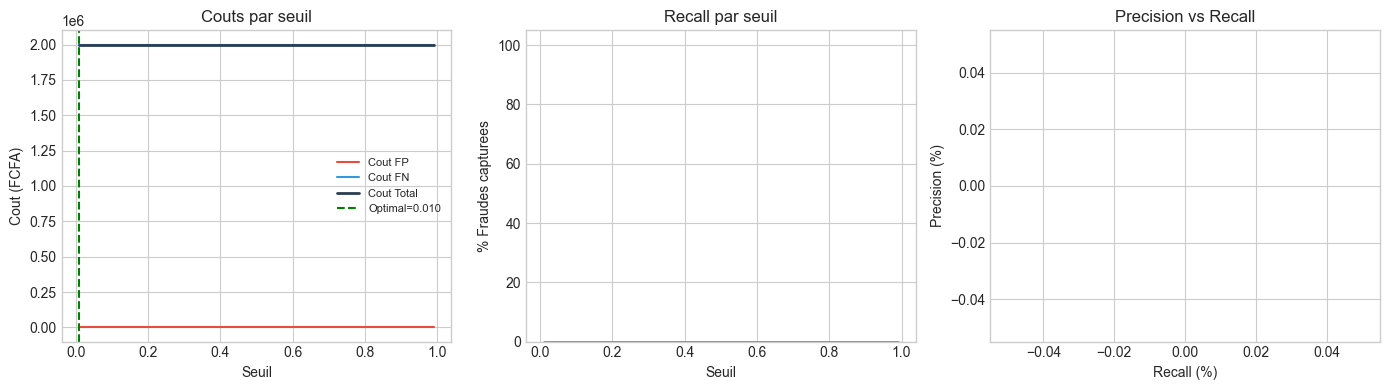

In [42]:
# Visualisation courbe cout-benefice
fig, axes = plt.subplots(1, 3, figsize=(14,4))
cb_sorted = cb_df.sort_values('threshold')

axes[0].plot(cb_sorted['threshold'], cb_sorted['cost_fp_total'], label='Cout FP', color='#e74c3c')
axes[0].plot(cb_sorted['threshold'], cb_sorted['cost_fn_total'], label='Cout FN', color='#3498db')
axes[0].plot(cb_sorted['threshold'], cb_sorted['cost_total'], label='Cout Total', color='#2c3e50', lw=2)
axes[0].axvline(optimal['threshold'], color='green', linestyle='--', label=f"Optimal={optimal['threshold']:.3f}")
axes[0].set_xlabel('Seuil'); axes[0].set_ylabel('Cout (FCFA)')
axes[0].set_title('Couts par seuil'); axes[0].legend(fontsize=8)

axes[1].plot(cb_sorted['threshold'], cb_sorted['frauds_caught_pct'], color='#27ae60', lw=2)
axes[1].set_xlabel('Seuil'); axes[1].set_ylabel('% Fraudes capturees')
axes[1].set_title('Recall par seuil'); axes[1].set_ylim(0, 105)

axes[2].plot(cb_sorted['frauds_caught_pct'], cb_sorted['precision']*100, color='#8e44ad', lw=2)
axes[2].set_xlabel('Recall (%)'); axes[2].set_ylabel('Precision (%)')
axes[2].set_title('Precision vs Recall');
plt.tight_layout(); plt.show()

# Phase 14 — Sauvegarde
---
Sauvegarde du meilleur modele et des metriques finales.

In [43]:
# Sauvegarder le modele ensemble et le scaler
os.makedirs(f'{ROOT}/outputs/models', exist_ok=True)
os.makedirs(f'{ROOT}/outputs/figures', exist_ok=True)

# Sauvegarder stacking model + composants
joblib.dump(stack_model, f'{ROOT}/outputs/models/stacking_ensemble.pkl')
joblib.dump(if_model, f'{ROOT}/outputs/models/isolation_forest.pkl')
joblib.dump(scaler, f'{ROOT}/outputs/models/scaler.pkl')
torch.save(ae_model.state_dict(), f'{ROOT}/outputs/models/autoencoder.pt')
joblib.dump(lgb_sup, f'{ROOT}/outputs/models/lightgbm_supervised.pkl')

# Sauvegarder les colonnes de features
joblib.dump(top40_cols, f'{ROOT}/outputs/models/feature_columns.pkl')
print('Modeles sauvegardes dans outputs/models/')

Modeles sauvegardes dans outputs/models/


In [44]:
# Metriques finales JSON
final_results = {
    'isolation_forest': if_metrics,
    'autoencoder': ae_metrics,
    'lightgbm': lgb_metrics,
    'ensemble_stacking': stack_metrics,
    'optimal_threshold': optimal,
    'n_train': int(len(y_behav)),
    'n_test': int(len(y_test_behav)),
    'fraud_rate_train': float(y_behav.mean()),
    'fraud_rate_test': float(y_test_behav.mean()),
    'top_features': list(top40_cols[:10]),
}
with open(f'{ROOT}/outputs/models/final_metrics.json', 'w') as f:
    json.dump(final_results, f, indent=2, default=float)
print('Metriques finales sauvegardees dans outputs/models/final_metrics.json')

Metriques finales sauvegardees dans outputs/models/final_metrics.json


## Resume des resultats

| Modele | AUC-PR | Recall@FPR=1% | Lift@1% |
|--------|--------|---------------|---------|

In [45]:
# Resume final
print('='*60)
print('  RESULTATS FINAUX — Detection de Fraude PayLink Africa')
print('='*60)
for name, m in [('Isolation Forest', if_metrics), ('Autoencoder', ae_metrics),
    ('LightGBM Supervise', lgb_metrics), ('Ensemble Stacking', stack_metrics)]:
    print(f'\n--- {name} ---')
    print(f'  AUC-PR:         {m["auc_pr"]:.4f}')
    print(f'  Recall@FPR=1%:  {m["recall_at_fpr_1pct"]:.4f}')
    print(f'  Lift@1%:        {m["lift_1pct"]:.1f}x')
    print(f'  Lift@5%:        {m["lift_5pct"]:.1f}x')
print(f'\nMeilleur seuil economique: {optimal["threshold"]:.3f} '
      f'(capture {optimal["frauds_caught_pct"]:.1f}% des fraudes)')
print(f'Cout total optimal: {optimal["cost_total"]:,.0f} FCFA')
print(f'ROI: {optimal["roi"]:.1f}x')
print('='*60)

  RESULTATS FINAUX — Detection de Fraude PayLink Africa

--- Isolation Forest ---
  AUC-PR:         0.0020
  Recall@FPR=1%:  0.0000
  Lift@1%:        0.0x
  Lift@5%:        0.0x

--- Autoencoder ---
  AUC-PR:         0.0013
  Recall@FPR=1%:  0.0000
  Lift@1%:        0.0x
  Lift@5%:        0.0x

--- LightGBM Supervise ---
  AUC-PR:         0.0053
  Recall@FPR=1%:  0.0000
  Lift@1%:        0.0x
  Lift@5%:        5.0x

--- Ensemble Stacking ---
  AUC-PR:         0.0008
  Recall@FPR=1%:  0.0000
  Lift@1%:        0.0x
  Lift@5%:        0.0x

Meilleur seuil economique: 0.010 (capture 0.0% des fraudes)
Cout total optimal: 2,000,000 FCFA
ROI: 0.0x
